# 2. Location Type Survey Statistics

In [1]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/add_treatment_to_df.R")
source("../util/samples_processing.R")

TREATMENT_DATES <- read_csv("../raw-data/treatment_dates.csv", col_names = TRUE)
ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")
PARTICIPANTS_TRAVEL_DATES <- read_rds("../R-table/PARTICIPANTS_TRAVEL_DATES.rds")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme


Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘HLMdiag’



In [2]:
locations_data_including_washout <- process_data_file(
    file_path = "../raw-data/locations.csv",
    ALL_PARTICIPANTS_METADATA = ALL_PARTICIPANTS_METADATA,
    only_during_intervention = FALSE
) |> 
    filter(!(treatment_boundary %in% c("before_start_first_half"))) |>
    filter(location_method == "survey")

locations_data_including_washout <- remove_duplicate_locations(data = locations_data_including_washout)


In [3]:
locations_data_including_washout

pseudonym,start_date,end_date,location_method,location_type,date,period_id,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order
<chr>,<dttm>,<dttm>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 02:30:00,2025-02-17 02:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 03:00:00,2025-02-17 03:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 03:30:00,2025-02-17 03:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 04:00:00,2025-02-17 04:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12


In [4]:
locations_data <- locations_data_including_washout |> filter(
    treatment %in% c(TREATMENT_1_NAME, TREATMENT_2_NAME) &
    !(treatment_boundary %in% c("before_start_second_half"))
) |> arrange(pseudonym, date)

## 2.1. Data availability - daily survey responses

In [5]:
# Max possible days (from treatment calendar)
max_days_df <- TREATMENT_DATES |>
  filter(!treatment_boundary %in% c("before_start_first_half", "before_start_second_half")) |>
  group_by(period_id) |>
  summarise(total_days = n_distinct(date), .groups = "drop") |>
  select(period_id, total_days)

location_survey_days <- locations_data |>
  filter(location_method == "survey") |>
  mutate(start_date = as_date(start_date)) |>
  distinct(pseudonym, period_id, survey_date = start_date)

survey_data_availability_by_participant <- location_survey_days |>
  group_by(pseudonym, period_id) |>
  summarise(days_with_survey = n(), .groups = "drop") |>
  arrange(period_id, pseudonym) |>
  left_join(max_days_df, by = c("period_id")) |>
  mutate(percentage = (days_with_survey / total_days) * 100) |>
  select(-period_id)
  
head(survey_data_availability_by_participant, n = 5)

pseudonym,days_with_survey,total_days,percentage
<chr>,<int>,<int>,<dbl>
apple3,28,34,82.35294
banana8,28,34,82.35294
burger4,28,34,82.35294
carrot7,24,34,70.58824
elephant1,28,34,82.35294


mean,sd,median,q25,q75
<dbl>,<dbl>,<int>,<dbl>,<dbl>
27.2439,1.771729,28,28,28


[1] 32

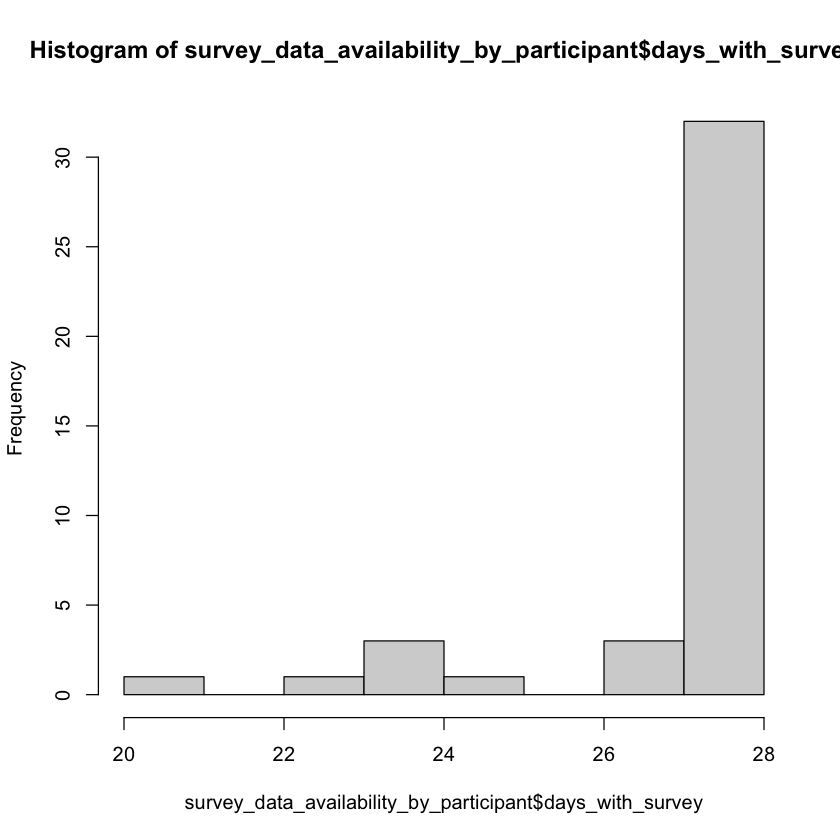

In [6]:
survey_data_availability_by_participant |>
  summarise(
    mean = mean(days_with_survey, na.rm = TRUE),
    sd = sd(days_with_survey, na.rm = TRUE),
    median = median(days_with_survey, na.rm = TRUE),
    q25 = quantile(days_with_survey, 0.25, na.rm = TRUE),
    q75 = quantile(days_with_survey, 0.75, na.rm = TRUE),
    .groups = "drop"
  )

nrow(survey_data_availability_by_participant |> filter(days_with_survey == 28))

hist(survey_data_availability_by_participant$days_with_survey)

## 2.2. Location type stats

In [7]:
locations_data_travel_removed <- remove_travel_dates(
    data = locations_data,
    participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
)

locations_data_including_washout_travel_removed <- remove_travel_dates(
    data = locations_data_including_washout,
    participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
)

### 2.2.1. Quick summarization for the entire cohort

In [8]:
LOCATION_TYPE_STATS <- locations_data_travel_removed |>
  group_by(location_type) |>
  summarise(
    percent = round(100 * n() / nrow(locations_data_travel_removed),2),
    .groups = "drop"
  ) 
LOCATION_TYPE_STATS

location_type,percent
<chr>,<dbl>
home,61.28
indoors,31.34
outdoors,7.37


### 2.2.2. Detailed summarization per participant

In [9]:
# All location types that should appear for every participant-date
all_location_types <- locations_data_including_washout_travel_removed |>
  distinct(location_type) |>
  pull(location_type)

# Metadata should be date-level, not location-type-level,
# so zero-hour location rows can inherit the correct treatment info.
location_date_metadata <- locations_data_including_washout_travel_removed |>
  mutate(
    treatment = case_when(
      treatment_boundary == "before_start_second_half" ~ "washout",
      TRUE ~ treatment
    ),
    first_or_second_half = case_when(
      treatment_boundary == "before_start_second_half" ~ "washout",
      TRUE ~ first_or_second_half
    )
  ) |>
  select(
    period_id,
    pseudonym,
    date,
    purifier_group,
    treatment,
    first_or_second_half,
    treatment_boundary,
    treatment_order
  ) |>
  distinct()

# Safety check: this table assumes one treatment/period metadata row per participant-date.
metadata_duplicates <- location_date_metadata |>
  count(pseudonym, date) |>
  filter(n > 1)

if (nrow(metadata_duplicates) > 0) {
  print(metadata_duplicates)
  stop("More than one metadata row found per pseudonym-date. Check treatment boundary/date structure before joining.")
}

LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT <- locations_data_including_washout_travel_removed |>
  group_by(pseudonym, date, location_type) |>
  summarise(
    hours = n() * 0.5,
    .groups = "drop"
  ) |>
  group_by(pseudonym, date) |>
  complete(
    location_type = all_location_types,
    fill = list(hours = 0)
  ) |>
  ungroup() |>
  left_join(
    location_date_metadata,
    by = c("pseudonym", "date")
  ) |>
  group_by(pseudonym, date) |>
  mutate(
    total_hours = sum(hours, na.rm = TRUE)
  ) |>
  filter(abs(total_hours - 24) < 1e-6) |>
  ungroup() |>
  select(
    period_id,
    pseudonym,
    date,
    location_type,
    hours,
    purifier_group,
    treatment,
    first_or_second_half,
    treatment_boundary,
    treatment_order
  ) |>
  arrange(pseudonym, date, desc(hours))

LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT

write_rds(
  LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT,
  file.path("../R-table", "LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT.rds")
)

period_id,pseudonym,date,location_type,hours,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order
<dbl>,<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,apple3,2025-02-17,home,17.0,X,treatment1,first_half,start_first_half,12
1,apple3,2025-02-17,indoors,5.5,X,treatment1,first_half,start_first_half,12
1,apple3,2025-02-17,outdoors,1.5,X,treatment1,first_half,start_first_half,12
1,apple3,2025-02-18,home,13.0,X,treatment1,first_half,NA,12
1,apple3,2025-02-18,indoors,8.0,X,treatment1,first_half,NA,12
1,apple3,2025-02-18,outdoors,3.0,X,treatment1,first_half,NA,12
1,apple3,2025-02-19,indoors,9.5,X,treatment1,first_half,NA,12
1,apple3,2025-02-19,home,9.0,X,treatment1,first_half,NA,12
1,apple3,2025-02-19,outdoors,5.5,X,treatment1,first_half,NA,12
